## Mount Google Drive
---

In [1]:
from google.colab import drive
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [2]:
cd /content/gdrive/MyDrive/Projects/FruitsVegetables/

/content/gdrive/MyDrive/Projects/FruitsVegetables


In [3]:
ls

fruit-and-vegetable-image-recognition/  FruitsVegetables.ipynb  ModelExperiments/


## Load dataset
---

In [4]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [5]:
ls

fruit-and-vegetable-image-recognition/  FruitsVegetables.ipynb  ModelExperiments/


In [6]:
train_dir = 'fruit-and-vegetable-image-recognition/train'
valid_dir = 'fruit-and-vegetable-image-recognition/validation'
test_dir = 'fruit-and-vegetable-image-recognition/test'

print('Training data:')
train_data = image_dataset_from_directory(directory=train_dir,
                                          label_mode='categorical',
                                          batch_size=None,
                                          image_size=(224,224))
print('Validation data:')
valid_data = image_dataset_from_directory(directory=valid_dir,
                                          label_mode='categorical',
                                          batch_size=None,
                                          image_size=(224,224))
print('Test data:')
test_data = image_dataset_from_directory(directory=test_dir,
                                         label_mode='categorical',
                                         batch_size=None,
                                         image_size=(224,224))

Training data:
Found 3115 files belonging to 36 classes.
Validation data:
Found 351 files belonging to 36 classes.
Test data:
Found 359 files belonging to 36 classes.


## Plotting random samples and visualizing some informations
---

In [7]:
import random
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [8]:
def plot_random_samples():
  target_dir = './fruit-and-vegetable-image-recognition/train'
  target_class = random.choice(os.listdir(target_dir))
  print(f'Plotting sample from {target_dir} directory and {target_class} class')
  image_path = random.choice(os.listdir(os.path.join(target_dir, target_class)))
  image = mpimg.imread(os.path.join(target_dir, target_class, image_path))

  print(f"""
  Image Shape:{image.shape}
  Image Data type:{image.dtype}
  Image Min Value:{image.min()}
  Image Max Value:{image.max()}
  """)
  plt.figure(figsize=(10, 5))
  plt.title(target_class)
  plt.imshow(image)
  plt.axis(False)
  plt.show()

Plotting sample from ./fruit-and-vegetable-image-recognition/train directory and tomato class

  Image Shape:(800, 700, 3)
  Image Data type:uint8
  Image Min Value:0
  Image Max Value:255
  


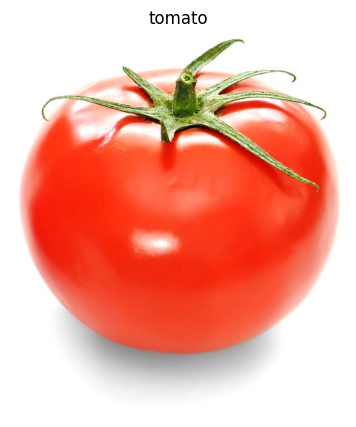

In [9]:
plot_random_samples()

## Preprocessing images
---

In [10]:
import tensorflow as tf

In [11]:
def preprocess_images(image, label):
  image = image/255.
  return tf.cast(image, dtype=tf.float32), label

In [12]:
train_data = train_data.map(map_func=preprocess_images, num_parallel_calls=tf.data.AUTOTUNE)
valid_data = valid_data.map(map_func=preprocess_images, num_parallel_calls=tf.data.AUTOTUNE)
test_data = test_data.map(map_func=preprocess_images, num_parallel_calls=tf.data.AUTOTUNE)

In [13]:
train_data,valid_data,test_data

(<_ParallelMapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(36,), dtype=tf.float32, name=None))>,
 <_ParallelMapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(36,), dtype=tf.float32, name=None))>,
 <_ParallelMapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(36,), dtype=tf.float32, name=None))>)

## Setting Global Precision Policy
---

In [14]:
tf.keras.mixed_precision.global_policy()

<DTypePolicy "float32">

In [15]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [16]:
tf.keras.mixed_precision.global_policy()

<DTypePolicy "mixed_float16">

## Creation of the datasets

---



In [17]:
train_dataset = train_data.batch(32).prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_data.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_data.batch(32).prefetch(tf.data.AUTOTUNE)

## Running some experiments
---

In [18]:
num_class = len(os.listdir(train_dir))
num_class

36

In [19]:
from tensorflow.keras import Sequential, layers
from tensorflow.keras.optimizers import Adam

#### Creation of some callbacks

In [20]:
def create_model_checkpoint(model_name, dir_path='ModelExperiments'):
  return tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(dir_path, f'{model_name}.keras'),
                                            save_best_only=True)

In [21]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(patience=3,
                                                 min_lr=1e-7)

early_stop = tf.keras.callbacks.EarlyStopping(patience=3)

#### Tranfer Learning : Resnet Model
---

In [22]:
base_model = tf.keras.applications.resnet_v2.ResNet50V2(include_top=False)
base_model.trainable=False #freeze model's layers

In [23]:
#Construct model using Functional API
inputs = layers.Input(shape=(224,224,3), dtype=tf.float16)
x = base_model(inputs, training=False) # set model in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(num_class)(x)
outputs = layers.Activation('softmax', dtype=tf.float32)(x)
model = tf.keras.Model(inputs, outputs, name='resnet_model')
#Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(),
              metrics=['accuracy'])

In [24]:
#Model summary
model.summary()

Model: "resnet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50v2 (Functional)              │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 36)                  │          73,764 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 36)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,638,564 (90.17 MB)

 Trainable params: 73,764 (288.14 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [25]:
#Fit the model
model_history = model.fit(train_dataset,
                          validation_data=(valid_dataset),
                          epochs=5)

Epoch 1/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 72s 568ms/step - accuracy: 0.3358 - loss: 2.5816 - val_accuracy: 0.8860 - val_loss: 0.5133
Epoch 2/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 382ms/step - accuracy: 0.8130 - loss: 0.6617 - val_accuracy: 0.9316 - val_loss: 0.3482
Epoch 3/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 386ms/step - accuracy: 0.8710 - loss: 0.4456 - val_accuracy: 0.9402 - val_loss: 0.2806
Epoch 4/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 390ms/step - accuracy: 0.9311 - loss: 0.3049 - val_accuracy: 0.9345 - val_loss: 0.2516
Epoch 5/5
98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 388ms/step - accuracy: 0.9496 - loss: 0.2273 - val_accuracy: 0.9573 - val_loss: 0.2068


#### Evaluate the model
---

In [26]:
# Evaluate the model
model.evaluate(test_dataset)

12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9629 - loss: 0.1840


[0.20419517159461975, 0.9582172632217407]

In [27]:
# plotting model history
def plot_history(model_history):
  acc, val_acc = model_history.history['accuracy'], model_history.history['val_accuracy']
  loss, val_loss = model_history.history['loss'], model_history.history['val_loss']
  epochs = range(len(loss))

  plt.figure(figsize=(10, 5))

  plt.subplot(1,2,1)
  plt.title('Accuracy')
  plt.plot(epochs, acc, label='Accuracy')
  plt.plot(epochs, val_acc, label='Val Accuracy')
  plt.legend()

  plt.subplot(1,2,2)
  plt.title('Loss')
  plt.plot(epochs, loss, label='Loss')
  plt.plot(epochs, val_loss, label='Val Loss')
  plt.legend()

  plt.show()


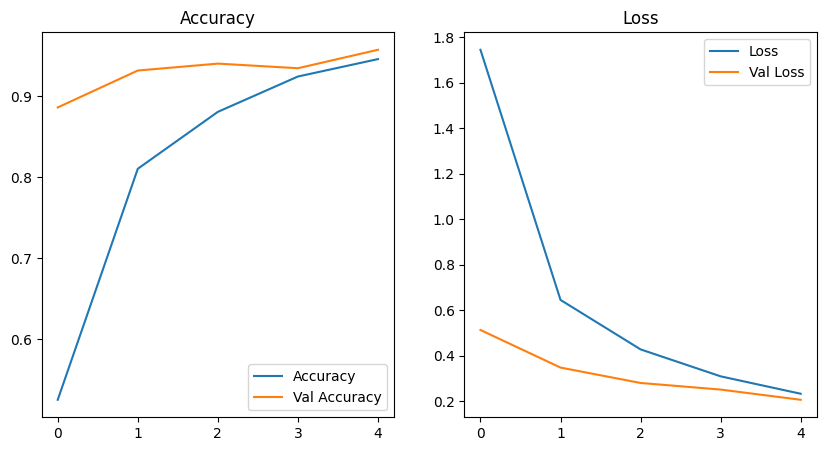

In [28]:
plot_history(model_history)

#### Fine-tune
---

In [29]:
base_model.trainable=True #unfreeze model's layers

In [30]:
#Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(0.0001),
              metrics=['accuracy'])

In [31]:
#Fit the model
model_history_fine_tune = model.fit(train_dataset,
                                    validation_data=(valid_dataset),
                                    epochs=100,
                                    callbacks=[create_model_checkpoint(model.name),
                                               reduce_lr,
                                               early_stop],
                                    initial_epoch=model_history.epoch[-1])

Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 160s 826ms/step - accuracy: 0.7990 - loss: 0.6815 - val_accuracy: 0.9459 - val_loss: 0.1901 - learning_rate: 1.0000e-04
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 442ms/step - accuracy: 0.9696 - loss: 0.1247 - val_accuracy: 0.9715 - val_loss: 0.1126 - learning_rate: 1.0000e-04
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 398ms/step - accuracy: 0.9823 - loss: 0.0731 - val_accuracy: 0.9715 - val_loss: 0.1224 - learning_rate: 1.0000e-04
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 37s 380ms/step - accuracy: 0.9872 - loss: 0.0383 - val_accuracy: 0.9744 - val_loss: 0.1168 - learning_rate: 1.0000e-04
Epoch 9/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 44s 453ms/step - accuracy: 0.9866 - loss: 0.0361 - val_accuracy: 0.9687 - val_loss: 0.1102 - learning_rate: 1.0000e-04
Epoch 10/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 438ms/step - accuracy: 0.9908 - loss: 0.0286 - val_accuracy: 0.9744 - val_loss: 0.1062 - learning_rate: 1.0000e-04
Epoch 11/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 45s 463ms/

In [32]:
##Loading best performing model
model = tf.keras.models.load_model('/content/gdrive/MyDrive/Projects/FruitsVegetables/ModelExperiments/resnet_model.keras')

In [33]:
## evaluate the model
model.evaluate(test_dataset)

12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 371ms/step - accuracy: 0.9780 - loss: 0.0752


[0.09949411451816559, 0.9721448421478271]

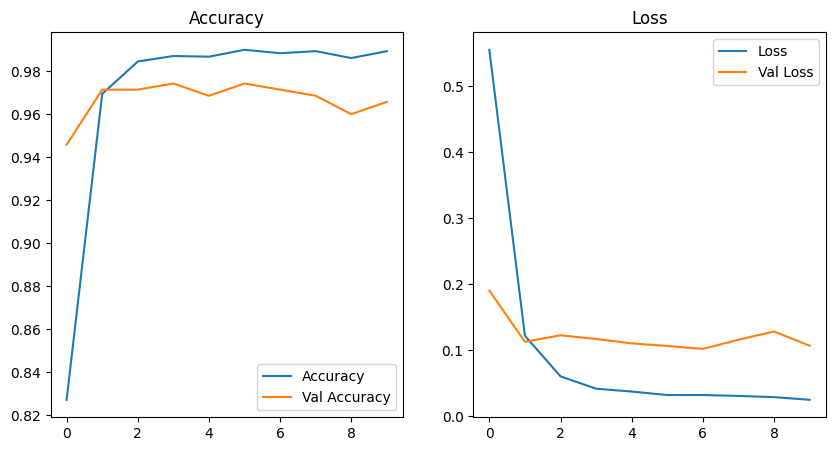

In [34]:
plot_history(model_history_fine_tune)